Task 2: Dataset Exploration

In [ ]:
##!pip install opencv-python

Number of classes: 4
Class Names: <StringArray>
['normal', 'scratch', 'dent', 'stain']
Length: 4, dtype: str

Images per class:
class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64

Sample Image Dimensions (H, W, C): (96, 96, 3)


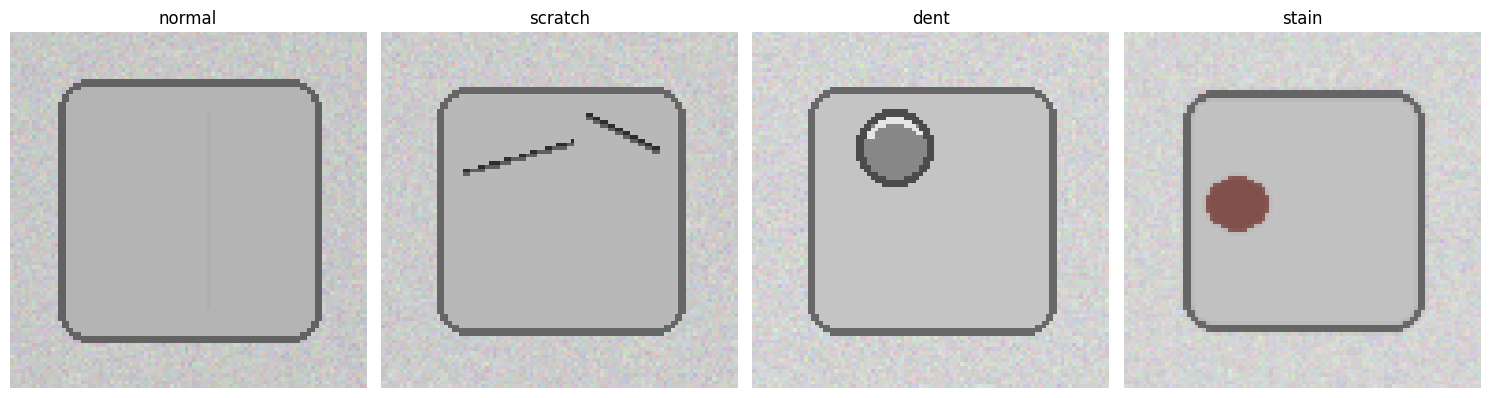

In [3]:
import pandas as pd
import cv2
import os
import matplotlib.pyplot as plt

# Load labels
df = pd.read_csv('labels.csv')

# 1. Number of classes
classes = df['class'].unique()
print(f"Number of classes: {len(classes)}")
print(f"Class Names: {classes}\n")

# 2. Number of images per class & checking imbalance
class_counts = df['class'].value_counts()
print("Images per class:")
print(class_counts)

# 3. Image Dimensions (Checking the first image as a sample)
sample_path = df['filename'].iloc[0]
if os.path.exists(sample_path):
    sample_img = cv2.imread(sample_path)
    print(f"\nSample Image Dimensions (H, W, C): {sample_img.shape}")
else:
    print("\nNote: Make sure the 'images/' folder structure matches the paths in labels.csv")

# 4. Visualize Sample Images from each class
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i, cls in enumerate(classes):
    sample_row = df[df['class'] == cls].iloc[0]
    img_path = sample_row['filename']
    
    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].set_title(cls)
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f'Missing:\n{cls}', ha='center', va='center')
        axes[i].axis('off')
plt.tight_layout()
plt.show()


Task 3: Image Preprocessing
This step loads, resizes, normalizes, and splits your data into training and test splits

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = 128  # Target fixed size

def load_and_preprocess_data(dataframe):
    X = []
    y = []
    
    for idx, row in dataframe.iterrows():
        img_path = row['filename']
        label = row['class']
        
        if os.path.exists(img_path):
            # Load and Resize
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            
            # Normalize pixel values to [0, 1]
            img = img / 255.0
            
            X.append(img)
            y.append(label)
            
    return np.array(X), np.array(y)

# Load features and labels
X, y = load_and_preprocess_data(df)

# Encode categorical labels to integers, then to one-hot vectors
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Stratified Splitting into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (384, 128, 128, 3)
Testing set shape: (96, 128, 128, 3)


Task 4: CNN Model Creation
Here we construct a Sequential CNN network containing all required elements using TensorFlow/Keras.

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models

def create_cnn_model(input_shape, num_classes):
    model = models.Sequential([
        # 1. Convolution + Activation
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        # 2. Pooling Layer
        layers.MaxPooling2D((2, 2)),
        
        # Second Block
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Third Block
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # 3. Flatten Layer
        layers.Flatten(),
        
        # 4. Dense Layer
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),  # Helps prevent overfitting
        
        # 5. Output Layer (Softmax for multi-class classification)
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

model = create_cnn_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=len(classes))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\nehaf\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Task 5: Model Training and Evaluation

In [ ]:
##!pip install seaborn

Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 540ms/step - accuracy: 0.2116 - loss: 1.5436 - val_accuracy: 0.2564 - val_loss: 1.3915
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 339ms/step - accuracy: 0.2783 - loss: 1.3954 - val_accuracy: 0.2564 - val_loss: 1.3848
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - accuracy: 0.2725 - loss: 1.3887 - val_accuracy: 0.3333 - val_loss: 1.3784
Epoch 4/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 334ms/step - accuracy: 0.3536 - loss: 1.3654 - val_accuracy: 0.5897 - val_loss: 1.3183
Epoch 5/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 333ms/step - accuracy: 0.4377 - loss: 1.2787 - val_accuracy: 0.6667 - val_loss: 1.1036
Epoch 6/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 324ms/step - accuracy: 0.5797 - loss: 1.0765 - val_accuracy: 0.6923 - val_loss: 0.8955
Epoch 7/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 347ms/step - accuracy: 0.5942 - loss: 0.8869 - val_accuracy: 0.6410 - val_loss: 0.7472
Epoch 8/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 254ms/step - accuracy: 0.7362 - loss: 0.6889 - val_accuracy: 0

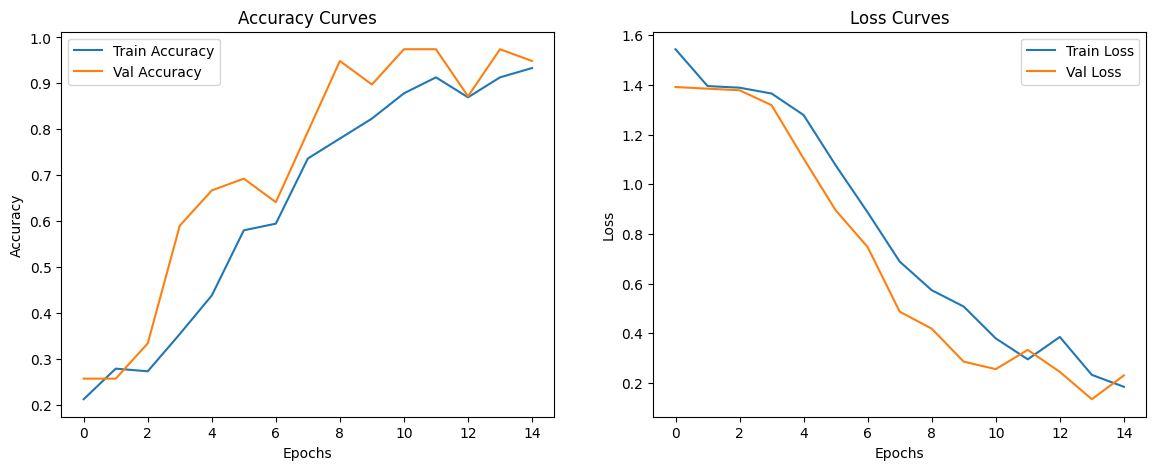


Test Accuracy: 0.9167
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


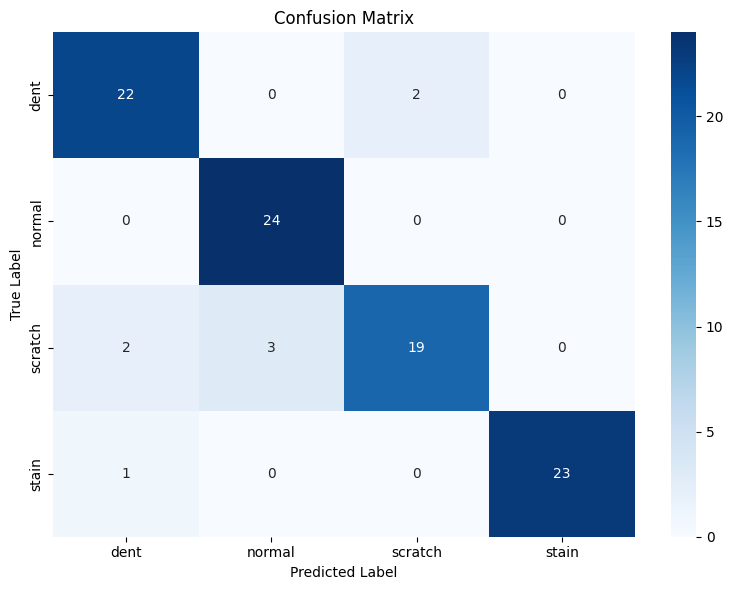

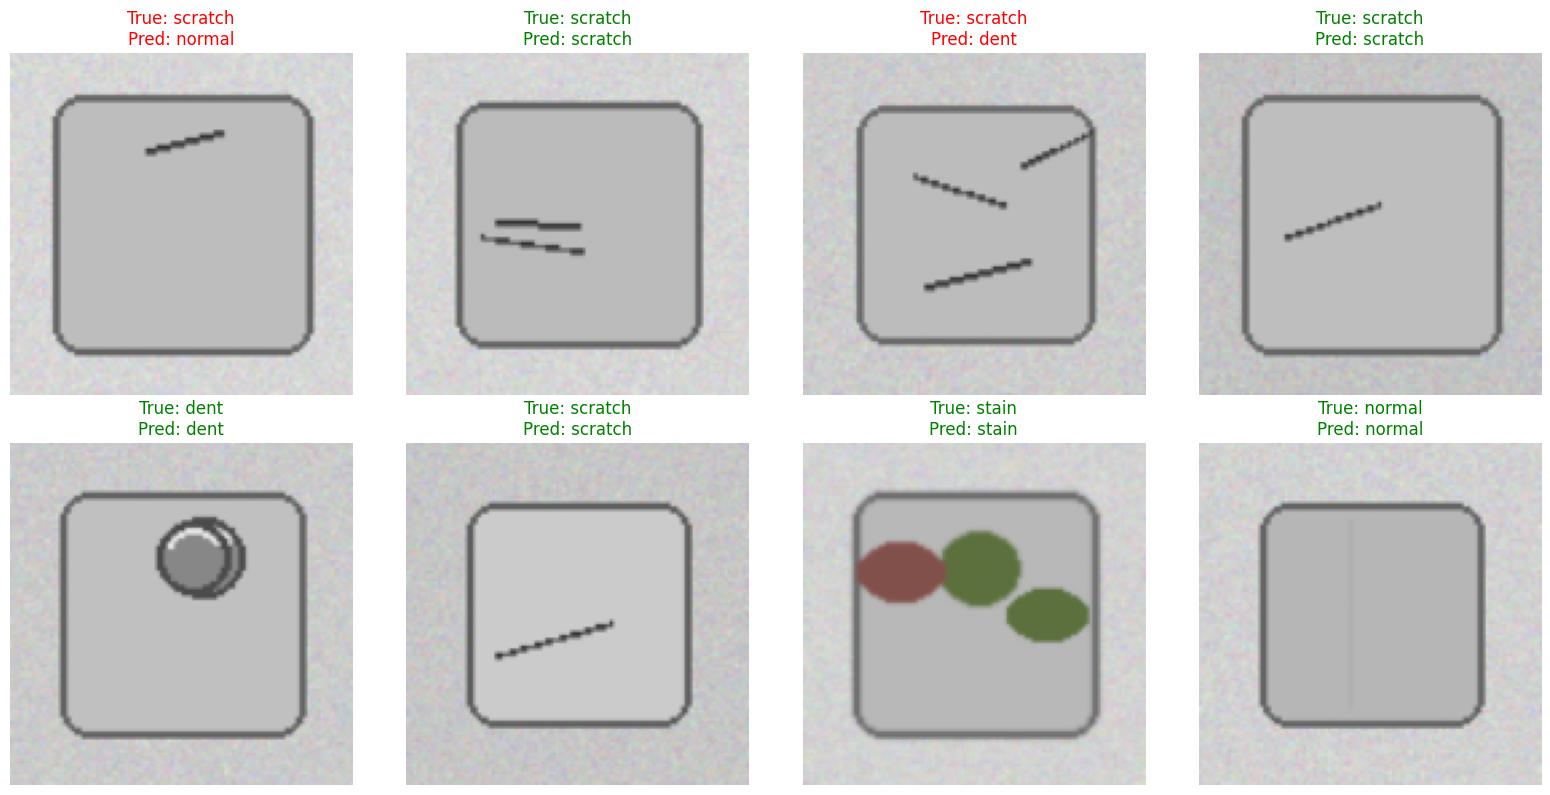

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Create required output folders
os.makedirs('results', exist_ok=True)
os.makedirs('sample_predictions', exist_ok=True)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.1,  # Carve out validation data from training split
    batch_size=32
)

# 1. Plot Training & Validation Accuracy/Loss Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy Curves')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss Curves')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

plt.savefig('results/accuracy_loss_curves.png')
plt.show()

# 2. Testing Performance & Confusion Matrix
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png')
plt.show()

# 3. Sample Predictions Plot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i in range(8):
    if i < len(X_test):
        axes[i].imshow(X_test[i])
        true_lbl = label_encoder.classes_[y_true_classes[i]]
        pred_lbl = label_encoder.classes_[y_pred_classes[i]]
        
        color = 'green' if true_lbl == pred_lbl else 'red'
        axes[i].set_title(f"True: {true_lbl}\nPred: {pred_lbl}", color=color)
        axes[i].axis('off')

plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png')
plt.show()